# Лабораторная работа 2. Кластеризация

Датасет: Chemical Composition of Ceramic Samples (UCI).

## Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv('Chemical Composion of Ceramic.csv')
print('Размер:', df.shape)
df.head()

Размер: (88, 19)


,Ceramic Name,Part,Na2O,MgO,Al2O3,SiO2,K2O,CaO,TiO2,Fe2O3,MnO,CuO,ZnO,PbO2,Rb2O,SrO,Y2O3,ZrO2,P2O5
0,FLQ-1-b,Body,0.62,0.38,19.61,71.99,4.84,0.31,0.07,1.18,630,10,70,10,430,0,40,80,90
1,FLQ-2-b,Body,0.57,0.47,21.19,70.09,4.98,0.49,0.09,1.12,380,20,80,40,430,-10,40,100,110
2,FLQ-3-b,Body,0.49,0.19,18.60,74.70,3.47,0.43,0.06,1.07,420,20,50,50,380,40,40,80,200
3,FLQ-4-b,Body,0.89,0.30,18.01,74.19,4.01,0.27,0.09,1.23,460,20,70,60,380,10,40,70,210
4,FLQ-5-b,Body,0.03,0.36,18.41,73.99,4.33,0.65,0.05,1.19,380,40,90,40,360,10,30,80,150


In [2]:
print(df['Part'].value_counts())
print()
print('Пропуски по столбцам:')
print(df.isna().sum())

Part
Body     44
Glaze    44
Name: count, dtype: int64

Пропуски по столбцам:
Ceramic Name    0
Part            0
Na2O            0
MgO             0
Al2O3           0
SiO2            0
K2O             0
CaO             0
TiO2            0
Fe2O3           0
MnO             0
CuO             0
ZnO             0
PbO2            0
Rb2O            0
SrO             0
Y2O3            0
ZrO2            0
P2O5            0
dtype: int64


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Na2O,88.0,0.471705,0.348779,0.03,0.2475,0.375,0.6425,1.88
MgO,88.0,0.430114,0.215030,0.07,0.2700,0.405,0.5300,1.32
Al2O3,88.0,17.460909,4.703422,11.30,13.0075,16.205,21.7075,26.48
SiO2,88.0,69.825114,2.754377,63.88,67.7375,69.990,71.8400,75.95
K2O,88.0,4.978409,0.879467,2.73,4.3375,5.065,5.5900,6.74
CaO,88.0,4.171818,4.305801,0.12,0.1800,2.690,7.9125,13.69
TiO2,88.0,0.101250,0.053430,0.04,0.0700,0.080,0.1300,0.29
Fe2O3,88.0,1.561591,0.604276,0.58,1.0975,1.510,1.9250,3.11
MnO,88.0,818.750000,614.240607,180.00,380.0000,590.000,982.5000,2970.00
CuO,88.0,30.909091,19.096630,0.00,20.0000,30.000,40.0000,80.00


## Отбор признаков и стандартизация

In [4]:
feature_cols = [c for c in df.columns if c not in ('Ceramic Name', 'Part')]
X_full = df[feature_cols].astype(float).values
labels_true = (df['Part'] == 'Glaze').astype(int).values
print('Признаки:', feature_cols)
print('Матрица признаков:', X_full.shape)

Признаки: ['Na2O', 'MgO', 'Al2O3', 'SiO2', 'K2O', 'CaO', 'TiO2', 'Fe2O3', 'MnO', 'CuO', 'ZnO', 'PbO2', 'Rb2O', 'SrO', 'Y2O3', 'ZrO2', 'P2O5']
Матрица признаков: (88, 17)


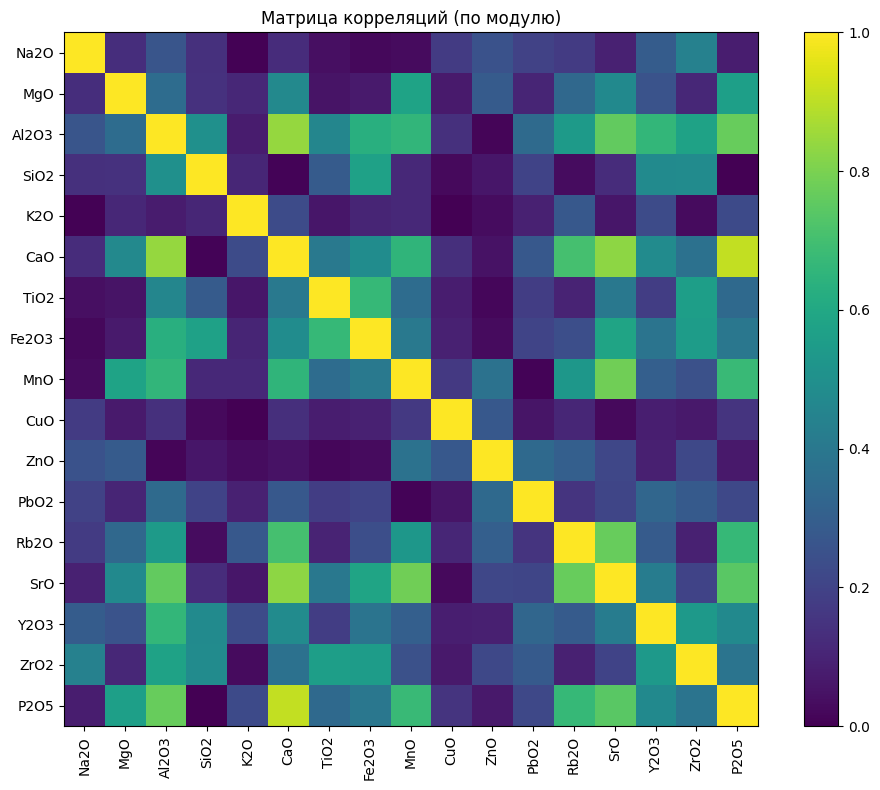

In [5]:
corr = df[feature_cols].corr().abs()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90)
ax.set_yticklabels(feature_cols)
plt.colorbar(im, ax=ax)
ax.set_title('Матрица корреляций (по модулю)')
plt.tight_layout()
plt.show()

In [6]:
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if corr.iloc[i, j] > 0.9:
            high_corr.append((feature_cols[i], feature_cols[j], corr.iloc[i, j]))

print('Пары с |r| > 0.9:')
for a, b, r in high_corr:
    print(f'  {a:6s} ~ {b:6s}  r={r:.3f}')

Пары с |r| > 0.9:
  CaO    ~ P2O5    r=0.908


In [7]:
to_drop = set()
for a, b, _ in high_corr:
    if a not in to_drop and b not in to_drop:
        to_drop.add(b)

selected = [c for c in feature_cols if c not in to_drop]
print('Удалено:', sorted(to_drop))
print('Осталось признаков:', len(selected))
print('Список:', selected)

Удалено: ['P2O5']
Осталось признаков: 16
Список: ['Na2O', 'MgO', 'Al2O3', 'SiO2', 'K2O', 'CaO', 'TiO2', 'Fe2O3', 'MnO', 'CuO', 'ZnO', 'PbO2', 'Rb2O', 'SrO', 'Y2O3', 'ZrO2']


In [8]:
X_raw = df[selected].astype(float).values
mean = X_raw.mean(axis=0)
std = X_raw.std(axis=0)
X = (X_raw - mean) / std
print('Среднее после стандартизации:', X.mean(axis=0).round(3))
print('Std после стандартизации:', X.std(axis=0).round(3))

Среднее после стандартизации: [-0.  0. -0. -0. -0.  0. -0. -0.  0. -0. -0. -0.  0. -0.  0. -0.]
Std после стандартизации: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## k-means++

In [9]:
def euclid_dist_matrix(A, B):
    diff = A[:, None, :] - B[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def kmeans_pp_init(X, k, rng):
    n = X.shape[0]
    centers = [X[rng.integers(n)]]
    for _ in range(1, k):
        d2 = euclid_dist_matrix(X, np.array(centers)).min(axis=1) ** 2
        probs = d2 / d2.sum()
        idx = rng.choice(n, p=probs)
        centers.append(X[idx])
    return np.array(centers)


def kmeans(X, k, max_iter=300, tol=1e-6, seed=0):
    rng = np.random.default_rng(seed)
    centers = kmeans_pp_init(X, k, rng)
    labels = np.zeros(X.shape[0], dtype=int)
    for _ in range(max_iter):
        dists = euclid_dist_matrix(X, centers)
        new_labels = dists.argmin(axis=1)
        new_centers = np.zeros_like(centers)
        for c in range(k):
            pts = X[new_labels == c]
            if len(pts) == 0:
                new_centers[c] = X[rng.integers(X.shape[0])]
            else:
                new_centers[c] = pts.mean(axis=0)
        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers
        labels = new_labels
        if shift < tol:
            break
    return labels, centers

## DBSCAN

In [10]:
def dbscan(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -1, dtype=int)
    visited = np.zeros(n, dtype=bool)
    dists = euclid_dist_matrix(X, X)
    cluster_id = 0
    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True
        neighbors = list(np.where(dists[i] <= eps)[0])
        if len(neighbors) < min_samples:
            continue
        labels[i] = cluster_id
        queue = neighbors
        while queue:
            j = queue.pop()
            if not visited[j]:
                visited[j] = True
                j_neighbors = list(np.where(dists[j] <= eps)[0])
                if len(j_neighbors) >= min_samples:
                    queue.extend(j_neighbors)
            if labels[j] == -1:
                labels[j] = cluster_id
        cluster_id += 1
    return labels

## Метрики: силуэт и ARI

In [11]:
def silhouette_score(X, labels):
    n = X.shape[0]
    unique = np.unique(labels)
    if len(unique) < 2:
        return 0.0
    dists = euclid_dist_matrix(X, X)
    s = np.zeros(n)
    for i in range(n):
        same = labels == labels[i]
        same[i] = False
        if same.sum() == 0:
            s[i] = 0
            continue
        a = dists[i, same].mean()
        b = np.inf
        for c in unique:
            if c == labels[i]:
                continue
            other = labels == c
            if other.sum() == 0:
                continue
            mean_d = dists[i, other].mean()
            if mean_d < b:
                b = mean_d
        s[i] = (b - a) / max(a, b)
    return s.mean()


def adjusted_rand_index(labels_true, labels_pred):
    from math import comb
    classes = np.unique(labels_true)
    clusters = np.unique(labels_pred)
    table = np.zeros((len(classes), len(clusters)), dtype=int)
    for i, c in enumerate(classes):
        for j, k in enumerate(clusters):
            table[i, j] = ((labels_true == c) & (labels_pred == k)).sum()
    sum_comb_table = sum(comb(n, 2) for n in table.flatten() if n >= 2)
    sum_comb_a = sum(comb(n, 2) for n in table.sum(axis=1) if n >= 2)
    sum_comb_b = sum(comb(n, 2) for n in table.sum(axis=0) if n >= 2)
    n_total = labels_true.shape[0]
    expected = sum_comb_a * sum_comb_b / comb(n_total, 2)
    max_index = (sum_comb_a + sum_comb_b) / 2
    if max_index == expected:
        return 0.0
    return (sum_comb_table - expected) / (max_index - expected)

## Подбор k для k-means++

k=2: silhouette=0.2626 ± 0.0273   inertia(min)=996.6
k=3: silhouette=0.2620 ± 0.0204   inertia(min)=798.5
k=4: silhouette=0.2303 ± 0.0247   inertia(min)=726.8


k=5: silhouette=0.2234 ± 0.0171   inertia(min)=658.7


k=6: silhouette=0.2097 ± 0.0237   inertia(min)=594.0
k=7: silhouette=0.2009 ± 0.0240   inertia(min)=546.1


k=8: silhouette=0.1836 ± 0.0284   inertia(min)=522.0


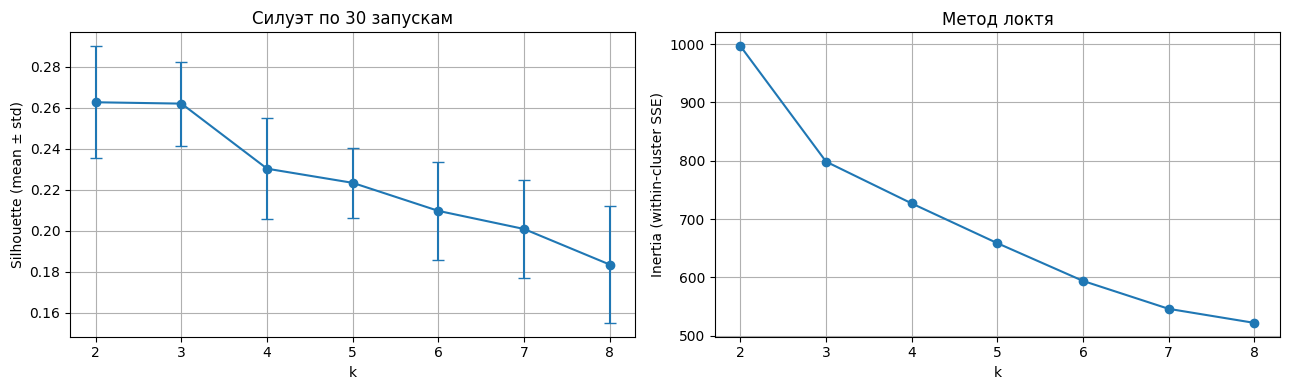

In [12]:
def kmeans_inertia(X, labels, centers):
    total = 0.0
    for c in range(len(centers)):
        pts = X[labels == c]
        if len(pts) > 0:
            total += ((pts - centers[c]) ** 2).sum()
    return total


ks = list(range(2, 9))
n_runs = 30

sil_mean = []
sil_std = []
inertia_min = []

for k in ks:
    sils = []
    inerts = []
    for seed in range(n_runs):
        labels, centers = kmeans(X, k, seed=seed)
        sils.append(silhouette_score(X, labels))
        inerts.append(kmeans_inertia(X, labels, centers))
    sil_mean.append(np.mean(sils))
    sil_std.append(np.std(sils))
    inertia_min.append(min(inerts))
    print(f'k={k}: silhouette={np.mean(sils):.4f} ± {np.std(sils):.4f}   inertia(min)={min(inerts):.1f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].errorbar(ks, sil_mean, yerr=sil_std, marker='o', capsize=4)
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette (mean ± std)')
axes[0].set_title('Силуэт по 30 запускам')
axes[0].grid(True)

axes[1].plot(ks, inertia_min, marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Inertia (within-cluster SSE)')
axes[1].set_title('Метод локтя')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [13]:
def pick_k(scores, ks, eps=0.005):
    best_score = max(scores)
    for k, s in zip(ks, scores):
        if best_score - s < eps:
            return k
    return ks[int(np.argmax(scores))]


best_k = pick_k(sil_mean, ks)
print(f'Выбранное k: {best_k}')

best_labels_km = None
best_score_km = -1
for seed in range(30):
    labels, _ = kmeans(X, best_k, seed=seed)
    score = silhouette_score(X, labels)
    if score > best_score_km:
        best_score_km = score
        best_labels_km = labels

print(f'k-means++ silhouette: {best_score_km:.4f}')
print(f'k-means++ ARI vs Part: {adjusted_rand_index(labels_true, best_labels_km):.4f}')
print('Размеры кластеров:', np.bincount(best_labels_km))

Выбранное k: 2
k-means++ silhouette: 0.2685
k-means++ ARI vs Part: 1.0000
Размеры кластеров: [44 44]


## Подбор параметров DBSCAN

In [14]:
n_total = X.shape[0]
max_noise_fraction = 0.3

best_dbscan = None
results = []
for eps in np.arange(1.5, 6.0, 0.25):
    for min_samples in [3, 4, 5, 6]:
        labels = dbscan(X, eps, min_samples)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters < 2:
            continue
        if n_noise / n_total > max_noise_fraction:
            continue
        mask = labels != -1
        score = silhouette_score(X[mask], labels[mask])
        results.append((eps, min_samples, n_clusters, n_noise, score))
        if best_dbscan is None or score > best_dbscan[2]:
            best_dbscan = (eps, min_samples, score, labels)

print(f'Подходящих конфигураций: {len(results)}')
print()
print('Топ-5 по силуэту:')
for row in sorted(results, key=lambda r: -r[4])[:5]:
    eps, ms, nc, nn, s = row
    print(f'  eps={eps:.2f} min_samples={ms} | clusters={nc} noise={nn} silhouette={s:.4f}')

Подходящих конфигураций: 4

Топ-5 по силуэту:
  eps=2.75 min_samples=3 | clusters=4 noise=25 silhouette=0.3183
  eps=3.00 min_samples=4 | clusters=3 noise=19 silhouette=0.3163
  eps=3.00 min_samples=3 | clusters=3 noise=18 silhouette=0.3144
  eps=3.00 min_samples=5 | clusters=4 noise=22 silhouette=0.2907


In [15]:
eps, min_samples, sil_db, labels_db = best_dbscan
print(f'Выбрано: eps={eps:.2f}, min_samples={min_samples}')
print(f'DBSCAN silhouette (без шума): {sil_db:.4f}')
print(f'DBSCAN ARI vs Part: {adjusted_rand_index(labels_true, labels_db):.4f}')
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'Найдено кластеров: {n_clusters}, шумовых точек: {n_noise}')

Выбрано: eps=2.75, min_samples=3
DBSCAN silhouette (без шума): 0.3183
DBSCAN ARI vs Part: 0.3150
Найдено кластеров: 4, шумовых точек: 25


## Визуализация через PCA

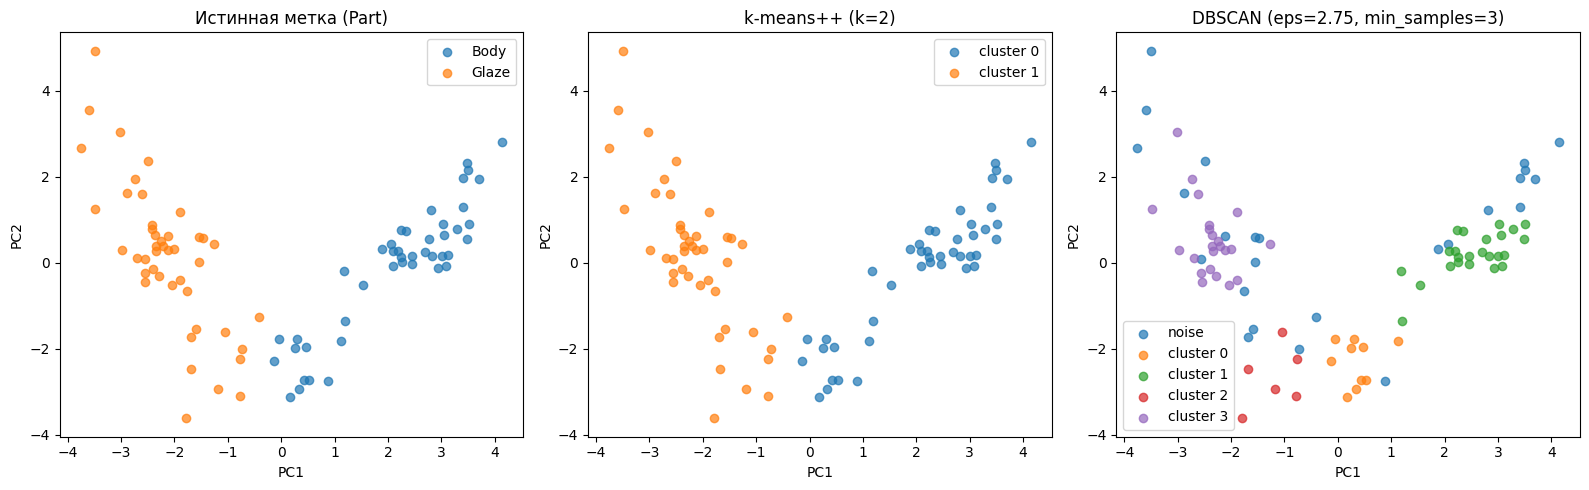

In [16]:
def pca_2d(X):
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc @ Vt[:2].T


X_2d = pca_2d(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for c, name in zip([0, 1], ['Body', 'Glaze']):
    axes[0].scatter(X_2d[labels_true == c, 0], X_2d[labels_true == c, 1], label=name, alpha=0.7)
axes[0].set_title('Истинная метка (Part)')
axes[0].legend()

for c in np.unique(best_labels_km):
    mask = best_labels_km == c
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], label=f'cluster {c}', alpha=0.7)
axes[1].set_title(f'k-means++ (k={best_k})')
axes[1].legend()

for c in np.unique(labels_db):
    mask = labels_db == c
    name = 'noise' if c == -1 else f'cluster {c}'
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1], label=name, alpha=0.7)
axes[2].set_title(f'DBSCAN (eps={eps:.2f}, min_samples={min_samples})')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

## Итог

In [17]:
print('Итог:')
print(f'{"Алгоритм":<15} {"Кластеров":<12} {"Silhouette":<12} {"ARI vs Part":<12}')
print('-' * 51)
ari_km = adjusted_rand_index(labels_true, best_labels_km)
ari_db = adjusted_rand_index(labels_true, labels_db)
print(f'{"k-means++":<15} {best_k:<12} {best_score_km:<12.4f} {ari_km:<12.4f}')
n_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f'{"DBSCAN":<15} {n_db:<12} {sil_db:<12.4f} {ari_db:<12.4f}')

Итог:
Алгоритм        Кластеров    Silhouette   ARI vs Part 
---------------------------------------------------
k-means++       2            0.2685       1.0000      
DBSCAN          4            0.3183       0.3150      
